In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


dataset_f = pd.read_csv('/content/fashion_sustainability_cleaned_final.csv')


a = dataset_f.rename(columns={'Recycling_Programs': 'LABEL'})


In [2]:
# Encode label column to 0 and 1
label_encoder = LabelEncoder()
dataset_f['LABEL'] = label_encoder.fit_transform(df['LABEL'])

# Separate features and label
X = dataset_f.drop(columns=['LABEL', 'Brand_Name'])
y = dataset_f['LABEL']

# Encode categorical features
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])


In [3]:
X_encoded.head()

,Country,Year,Sustainability_Rating,Material_Type,Eco_Friendly_Manufacturing,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG,Product_Lines,Average_Price_USD,Market_Trend,Certifications
0,1,2015,2,1,1,85.13,1308839.48,60047.04,5,328.81,1,2
1,7,2023,1,5,0,358.73,1568552.21,78799.16,5,240.02,1,0
2,1,2014,1,0,1,330.49,4791168.72,77917.88,7,161.91,0,0
3,1,2016,3,3,1,277.11,3023687.50,10916.38,3,375.71,0,3
4,4,2016,3,2,1,405.52,3579678.54,15449.83,20,112.55,1,0


In [4]:
y.head()

,LABEL
0,1
1,0
2,1
3,1
4,1


In [5]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [6]:
X_train.head()

,Country,Year,Sustainability_Rating,Material_Type,Eco_Friendly_Manufacturing,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG,Product_Lines,Average_Price_USD,Market_Trend,Certifications
3245,2,2021,1,1,1,473.62,3858119.33,45348.93,6,284.08,0,2
2018,2,2023,3,4,0,363.07,4777717.49,81925.73,2,157.66,1,3
1672,9,2013,0,0,0,427.57,1424802.54,13580.83,10,330.75,2,4
3667,3,2011,1,5,1,442.79,3668414.09,94340.78,6,244.77,1,2
831,7,2024,3,1,0,421.24,1011418.79,74594.12,12,460.67,1,3


In [7]:
X_test.head()

,Country,Year,Sustainability_Rating,Material_Type,Eco_Friendly_Manufacturing,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG,Product_Lines,Average_Price_USD,Market_Trend,Certifications
4872,8,2018,1,2,1,164.49,3095324.88,40984.12,9,439.50,1,4
1025,5,2011,1,3,0,481.39,4906438.37,27322.55,5,135.05,0,2
3192,7,2023,2,2,1,235.57,3925874.48,69606.67,18,281.82,0,3
2894,8,2014,2,5,0,81.63,286898.01,72927.63,18,431.78,2,1
4392,5,2018,2,1,0,452.37,2319609.90,77129.15,12,317.12,1,2


In [8]:
y_train.head()

,LABEL
3245,1
2018,0
1672,1
3667,0
831,0


In [9]:
y_test.head()

,LABEL
4872,0
1025,0
3192,1
2894,1
4392,0


XGBOOST

In [10]:

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:39:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [11]:

y_pred = xgb_model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['No', 'Yes']))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy Score: 0.514456630109671

Classification Report:
               precision    recall  f1-score   support

          No       0.51      0.49      0.50       493
         Yes       0.52      0.54      0.53       510

    accuracy                           0.51      1003
   macro avg       0.51      0.51      0.51      1003
weighted avg       0.51      0.51      0.51      1003


Confusion Matrix:
 [[240 253]
 [234 276]]


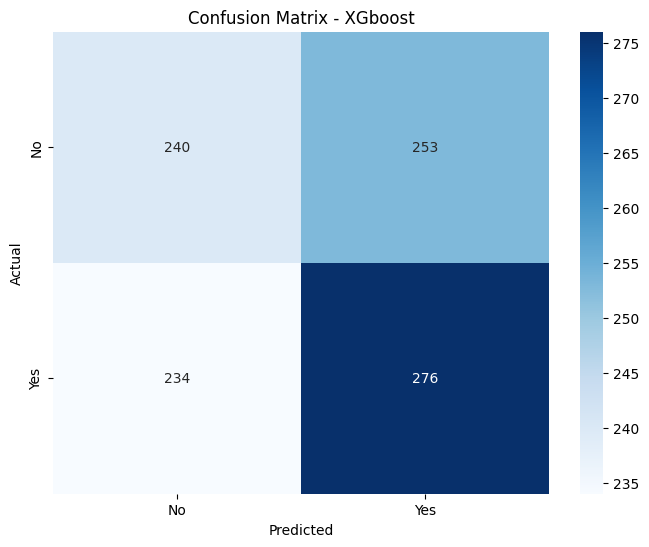

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGboost')
plt.show()

RANDOM FOREST

In [13]:
from sklearn.ensemble import RandomForestClassifier


In [14]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [15]:

y_pred_rf = rf_model.predict(X_test)

print("Accuracy Score (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Accuracy Score (Random Forest): 0.47756729810568294

Classification Report:
               precision    recall  f1-score   support

          No       0.47      0.47      0.47       493
         Yes       0.49      0.48      0.49       510

    accuracy                           0.48      1003
   macro avg       0.48      0.48      0.48      1003
weighted avg       0.48      0.48      0.48      1003


Confusion Matrix:
 [[232 261]
 [263 247]]


In [24]:
import matplotlib.pyplot as plt

# Define combinations of parameters
estimators = [50, 100, 150, 200]
depths = [5, 10, 15, None]

results = []

for n in estimators:
    for d in depths:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        rf.fit(X_train, y_train)
        acc = accuracy_score(y_test, rf.predict(X_test))
        results.append({'n_estimators': n, 'max_depth': d if d is not None else 'None', 'accuracy': acc})


In [25]:
import seaborn as sns

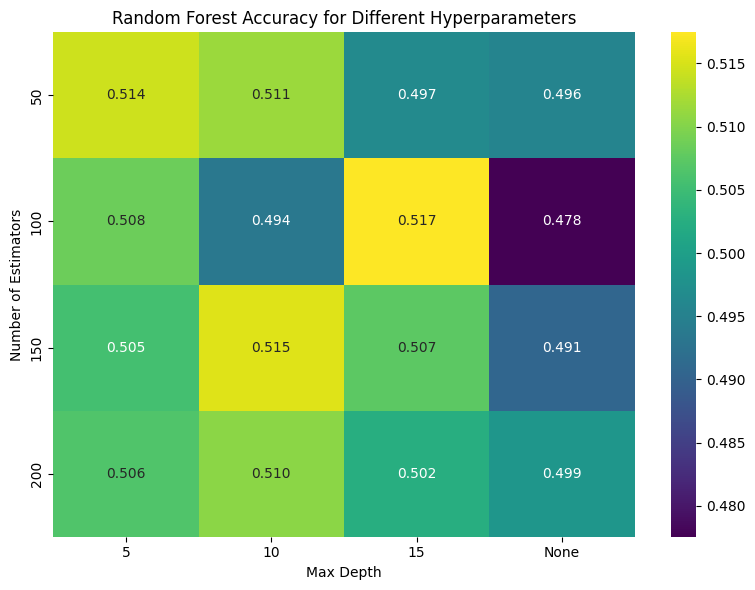

In [26]:
# Convert results to DataFrame
rf_results_df = pd.DataFrame(results)

# Pivot for heatmap-style visualization
pivot_table = rf_results_df.pivot(index='n_estimators', columns='max_depth', values='accuracy')

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.title("Random Forest Accuracy for Different Hyperparameters")
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".3f")
plt.xlabel("Max Depth")
plt.ylabel("Number of Estimators")
plt.tight_layout()
plt.show()


STACKING

In [16]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression


In [17]:

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

final_estimator = LogisticRegression()


In [18]:

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=final_estimator,
    passthrough=True,
    cv=5
)


stack_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:40:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:40:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:40:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:40:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:40:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None, gamma=None,
                                              grow_policy=None,
                                              im...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...))],
                   final_estimator=LogisticRegression(), passthrough=True)

In [19]:

y_pred_stack = stack_model.predict(X_test)

print("Accuracy Score (Stacking):", accuracy_score(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack, target_names=['No', 'Yes']))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))


Accuracy Score (Stacking): 0.49750747756729813

Classification Report:
               precision    recall  f1-score   support

          No       0.49      0.44      0.46       493
         Yes       0.51      0.55      0.53       510

    accuracy                           0.50      1003
   macro avg       0.50      0.50      0.50      1003
weighted avg       0.50      0.50      0.50      1003


Confusion Matrix:
 [[217 276]
 [228 282]]


ADABOOST

In [20]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


In [21]:

base_dt = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_model = AdaBoostClassifier(n_estimators=50, random_state=42)
ada_model.fit(X_train, y_train)

AdaBoostClassifier(random_state=42)

In [22]:

y_pred_ada = ada_model.predict(X_test)

print("Accuracy Score (AdaBoost):", accuracy_score(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada, target_names=['No', 'Yes']))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))


Accuracy Score (AdaBoost): 0.514456630109671

Classification Report:
               precision    recall  f1-score   support

          No       0.51      0.43      0.47       493
         Yes       0.52      0.59      0.55       510

    accuracy                           0.51      1003
   macro avg       0.51      0.51      0.51      1003
weighted avg       0.51      0.51      0.51      1003


Confusion Matrix:
 [[214 279]
 [208 302]]


In [23]:
import pandas as pd


model_names = ['XGBoost', 'Random Forest', 'Stacking', 'AdaBoost']
accuracies = [
    accuracy_score(y_test, y_pred),         # XGBoost
    accuracy_score(y_test, y_pred_rf),      # Random Forest
    accuracy_score(y_test, y_pred_stack),   # Stacking
    accuracy_score(y_test, y_pred_ada)      # AdaBoost
]


comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})


print(comparison_df)


           Model  Accuracy
0        XGBoost  0.514457
1  Random Forest  0.477567
2       Stacking  0.497507
3       AdaBoost  0.514457


Using 100–150 estimators with moderate depth (10–15) strikes the best balance between bias and variance, offering the highest accuracy on your fashion sustainability dataset.


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay



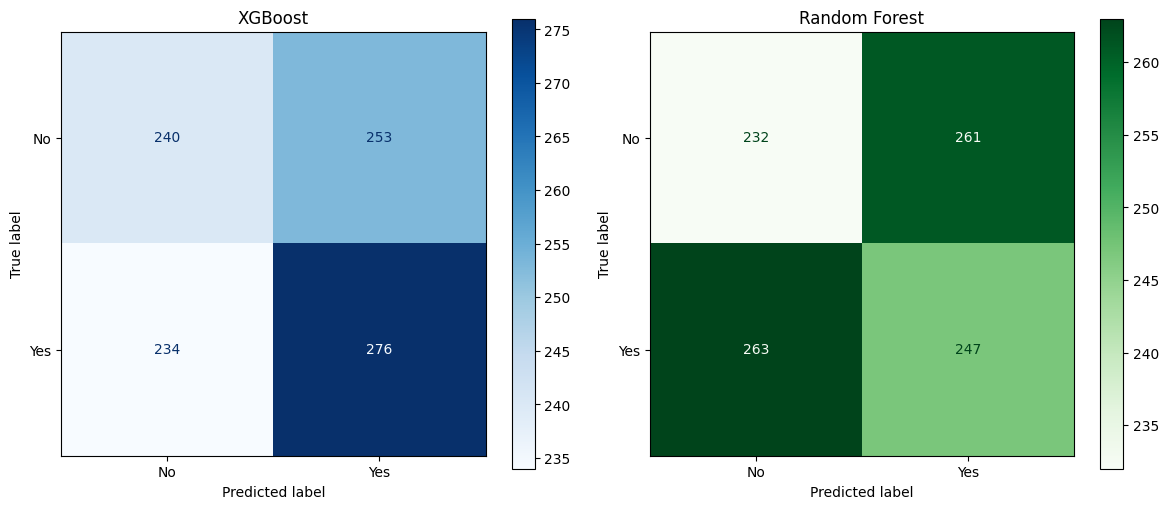

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'], ax=axes[0], cmap='Blues')
axes[0].set_title("XGBoost")

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['No', 'Yes'], ax=axes[1], cmap='Greens')
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()


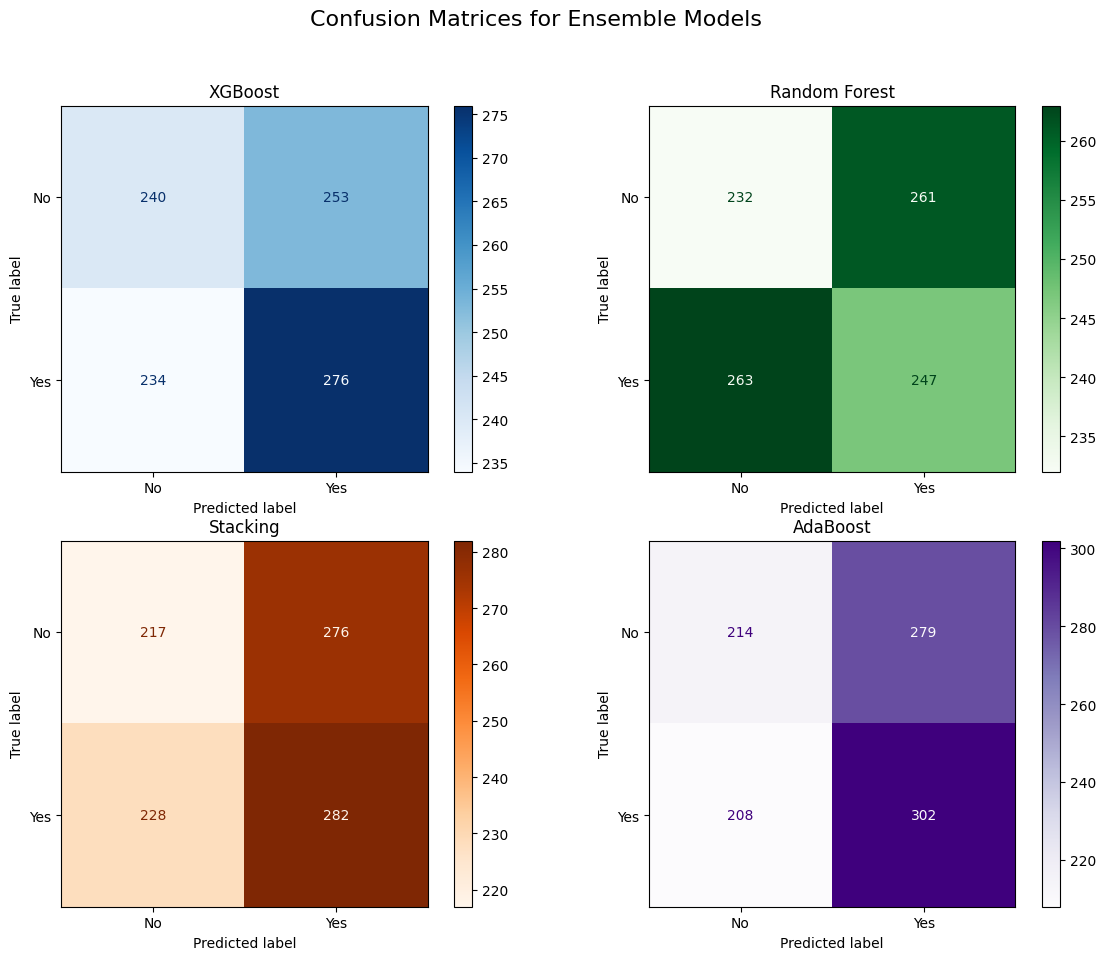

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices for Ensemble Models", fontsize=16)

# XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'], ax=axes[0, 0], cmap='Blues')
axes[0, 0].set_title("XGBoost")

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['No', 'Yes'], ax=axes[0, 1], cmap='Greens')
axes[0, 1].set_title("Random Forest")

# Stacking
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_stack, display_labels=['No', 'Yes'], ax=axes[1, 0], cmap='Oranges')
axes[1, 0].set_title("Stacking")

# AdaBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ada, display_labels=['No', 'Yes'], ax=axes[1, 1], cmap='Purples')
axes[1, 1].set_title("AdaBoost")


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
